In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
import numpy as np

In [6]:
# Gerador reprodutível (seed=42): mesmos pontos a cada execução.
rng = np.random.default_rng(42)


def z_samples(x, y, rng, noise_std=0.1):
    """Calcula z = f(x, y) + ruído; x e y devem ter a mesma forma (1D aqui).

    - sin(x)*cos(y): parte suave da superfície (exemplo didático).
    - ruído gaussiano ~ N(0, noise_std): imita medição ruidosa; os pontos não formam grade retangular.
    """
    sinal = np.sin(x) * np.cos(y)
    ruido = noise_std * rng.standard_normal(np.shape(x))
    return sinal + ruido


# Amostras aleatórias no quadrado [-3, 3]². plot_trisurf triangula no plano xy (Delaunay) e levanta z.
n = 400
x = rng.uniform(-3, 3, n)
y = rng.uniform(-3, 3, n)
z = z_samples(x, y, rng)


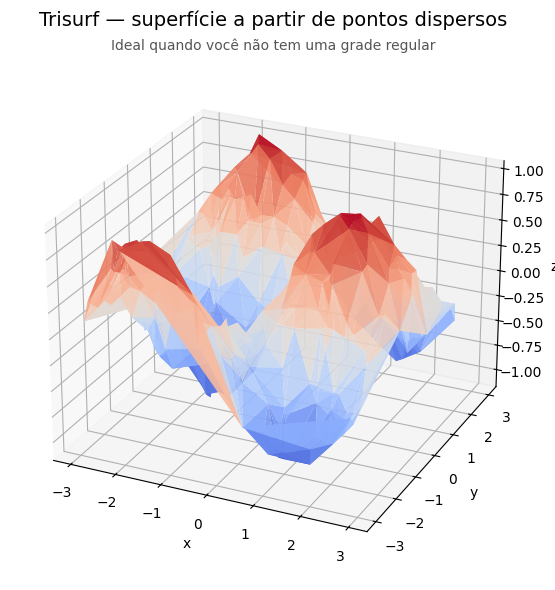

In [7]:
# trisurf: une os pontos (x,y,z) com uma malha de TRIÂNGULOS (não exige grade retangular).
# O algoritmo triangula a projeção (x,y) e interpola z em cada face — ideal para dados dispersos.
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(x, y, z, cmap="coolwarm", edgecolor="none", alpha=0.9)

ax.set_title("Trisurf — superfície a partir de pontos dispersos", fontsize=14, pad=20)
ax.text2D(
    0.5,
    1,
    "Ideal quando você não tem uma grade regular",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=25, azim=-65)

plt.tight_layout()
plt.savefig("trisurf.png", dpi=1000)
plt.show()